<a href="https://colab.research.google.com/github/nashish109/smart-ecommerce-fraud-detection/blob/main/TermPaperProj.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [ ]:
import torch
print("CUDA Available:", torch.cuda.is_available())
print("GPU Name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU detected")

CUDA Available: False
GPU Name: No GPU detected


Class Distribution:
 Is Fraudulent
0    22412
1     1222
Name: count, dtype: int64


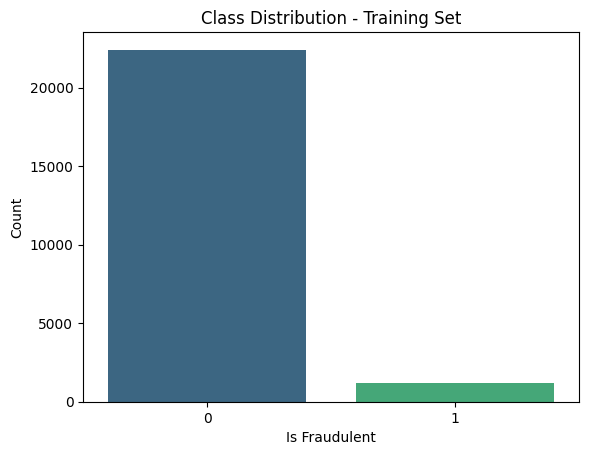

Preprocessing completed successfully!


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression

# Load dataset
train_df = pd.read_csv('/content/Fraudulent_E-Commerce_Transaction_Data_2.csv')
test_df = pd.read_csv('/content/Fraudulent_E-Commerce_Transaction_Data_2.csv')

# Preprocessing function
def clean_data(df) -> pd.DataFrame:
    df["Transaction Date"] = pd.to_datetime(df["Transaction Date"])
    df['Transaction Day'] = df["Transaction Date"].dt.day
    df["Transaction DOW"] = df["Transaction Date"].dt.day_of_week
    df["Transaction Month"] = df["Transaction Date"].dt.month

    mean_value = np.round(df['Customer Age'].mean(), 0)
    df['Customer Age'] = np.where(df['Customer Age'] <= -9,
                                    np.abs(df['Customer Age']),
                                    df['Customer Age'])
    df['Customer Age'] = np.where(df['Customer Age'] < 9,
                                    mean_value,
                                    df['Customer Age'])
    df["Is Address Match"] = (df["Shipping Address"] == df["Billing Address"]).astype(int)

    df.drop(columns=["Transaction ID", "Customer ID", "Customer Location",
                     "IP Address", "Transaction Date", "Shipping Address", "Billing Address"], inplace=True)

    int_col = df.select_dtypes(include="int").columns
    float_col = df.select_dtypes(include="float").columns
    df[int_col] = df[int_col].apply(pd.to_numeric, downcast='integer')
    df[float_col] = df[float_col].apply(pd.to_numeric, downcast='float')

    return df

# Clean training and test data
train_df = clean_data(train_df)
test_df = clean_data(test_df)

# Split features and target
X = train_df.drop(columns=['Is Fraudulent'])
y = train_df['Is Fraudulent']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Check class distribution
class_counts = train_df['Is Fraudulent'].value_counts()
print("Class Distribution:\n", class_counts)

# Plot class distribution
sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")
plt.title("Class Distribution - Training Set")
plt.xlabel("Is Fraudulent")
plt.ylabel("Count")
plt.show()

# Separate categorical and numerical columns
cat_col = X_train.select_dtypes(include="O").columns
num_col = [col for col in X_train.columns if col not in cat_col and col != 'Is Address Match']

# Apply OneHotEncoder for categorical features and StandardScaler for numerical features
preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_col),
    ('num', StandardScaler(), num_col)
])

# Transform X_train to numerical
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

print("Preprocessing completed successfully!")

Class Distribution After SMOTE:
 Is Fraudulent
0    17927
1    17927
Name: count, dtype: int64


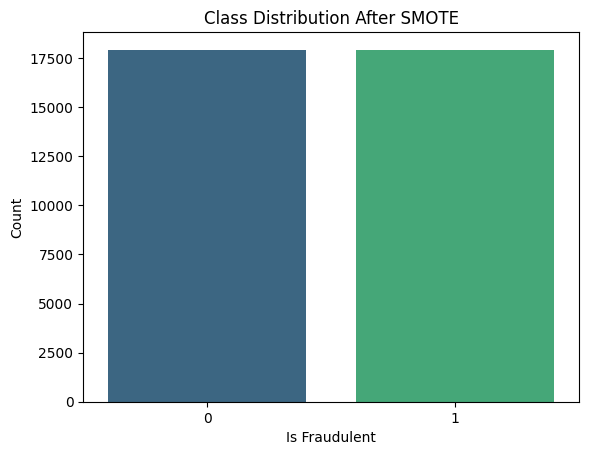

In [ ]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_transformed, y_train)

# Check results
smote_counts = pd.Series(y_train_smote).value_counts()
print("Class Distribution After SMOTE:\n", smote_counts)

# Visualize the distribution
sns.barplot(x=smote_counts.index, y=smote_counts.values, palette="viridis")
plt.title("Class Distribution After SMOTE")
plt.xlabel("Is Fraudulent")
plt.ylabel("Count")
plt.show()


Random Forest - Original Data
Accuracy: 0.9904375052889904
Confusion Matrix:
 [[22405     7]
 [  219  1003]]
Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99     22412
           1       0.99      0.82      0.90      1222

    accuracy                           0.99     23634
   macro avg       0.99      0.91      0.95     23634
weighted avg       0.99      0.99      0.99     23634



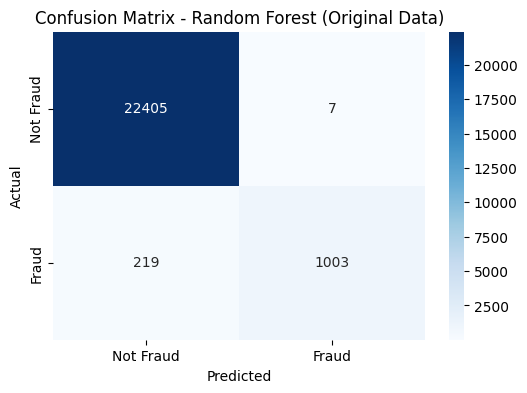


Logistic Regression - Original Data
Accuracy: 0.9533722603029534
Confusion Matrix:
 [[22389    23]
 [ 1079   143]]
Classification Report:
               precision    recall  f1-score   support

           0       0.95      1.00      0.98     22412
           1       0.86      0.12      0.21      1222

    accuracy                           0.95     23634
   macro avg       0.91      0.56      0.59     23634
weighted avg       0.95      0.95      0.94     23634



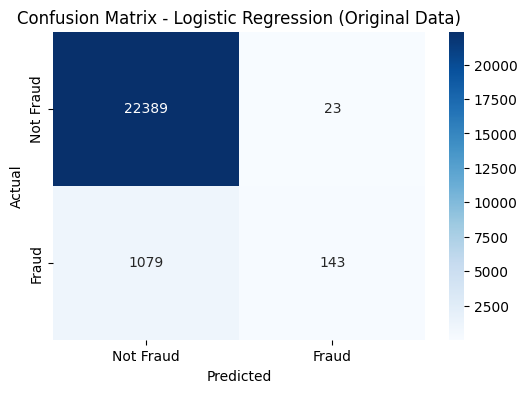


XGBoost - Original Data
Accuracy: 0.9753321485994754
Confusion Matrix:
 [[22374    38]
 [  545   677]]
Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99     22412
           1       0.95      0.55      0.70      1222

    accuracy                           0.98     23634
   macro avg       0.96      0.78      0.84     23634
weighted avg       0.97      0.98      0.97     23634



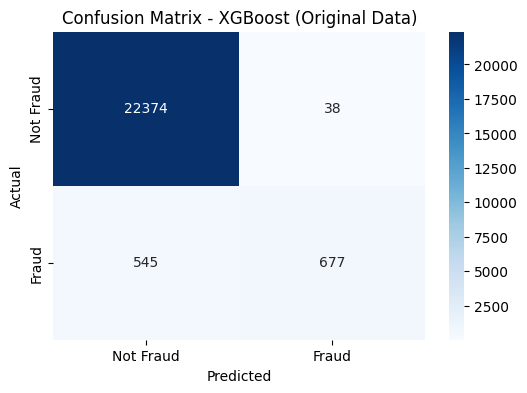


Random Forest - SMOTE Data
Accuracy: 0.9888719641194889
Confusion Matrix:
 [[22353    59]
 [  204  1018]]
Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99     22412
           1       0.95      0.83      0.89      1222

    accuracy                           0.99     23634
   macro avg       0.97      0.92      0.94     23634
weighted avg       0.99      0.99      0.99     23634



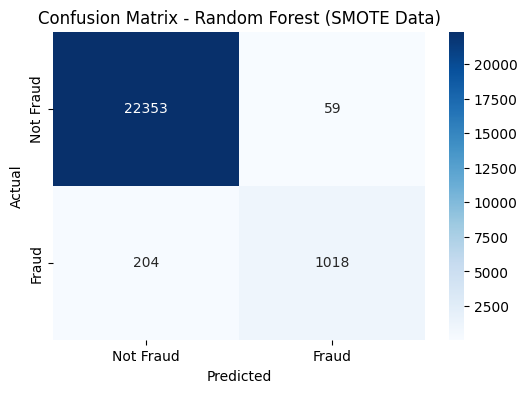


Logistic Regression - SMOTE Data
Accuracy: 0.7292460015232293
Confusion Matrix:
 [[16395  6017]
 [  382   840]]
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.73      0.84     22412
           1       0.12      0.69      0.21      1222

    accuracy                           0.73     23634
   macro avg       0.55      0.71      0.52     23634
weighted avg       0.93      0.73      0.80     23634



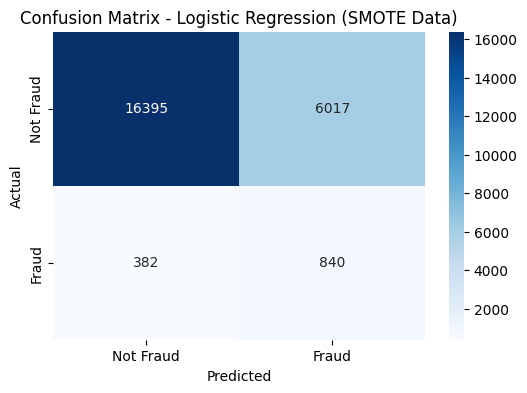


XGBoost - SMOTE Data
Accuracy: 0.9723280020309724
Confusion Matrix:
 [[22375    37]
 [  617   605]]
Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.99     22412
           1       0.94      0.50      0.65      1222

    accuracy                           0.97     23634
   macro avg       0.96      0.75      0.82     23634
weighted avg       0.97      0.97      0.97     23634



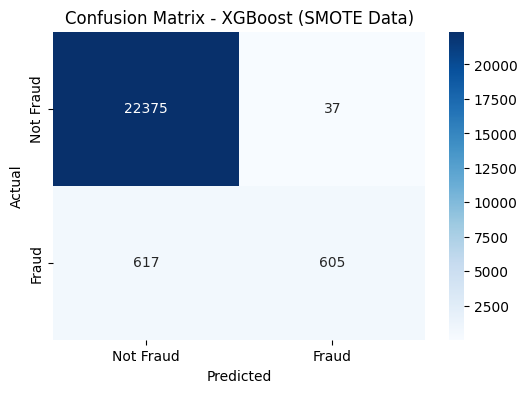

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression  # Using Logistic Regression for classification
from xgboost import XGBClassifier

# Define classifiers
classifiers = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),  # Used instead of Linear Regression
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
}

# Train models
def train_and_evaluate(X_train, y_train, X_test, y_test, desc):
    results = []
    for name, classifier in classifiers.items():
        model = Pipeline(steps=[
            ('classifier', classifier)
        ])
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        acc = accuracy_score(y_test, preds)
        cm = confusion_matrix(y_test, preds)

        print(f"\n{name} - {desc}")
        print("Accuracy:", acc)
        print("Confusion Matrix:\n", cm)
        print("Classification Report:\n", classification_report(y_test, preds))

        # Plot heatmap
        plt.figure(figsize=(6, 4))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Fraud', 'Fraud'], yticklabels=['Not Fraud', 'Fraud'])
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.title(f'Confusion Matrix - {name} ({desc})')
        plt.show()

        results.append((name, acc))
    return results

# Transform test data
X_test_transformed = preprocessor.transform(test_df.drop(columns=["Is Fraudulent"]))

# Train models on original and SMOTE data
results_original = train_and_evaluate(X_train_transformed, y_train, X_test_transformed, test_df["Is Fraudulent"], "Original Data")
results_smote = train_and_evaluate(X_train_smote, y_train_smote, X_test_transformed, test_df["Is Fraudulent"], "SMOTE Data")


Comparison of Results:
                 Model  Accuracy (Original)  Accuracy (SMOTE)
0        Random Forest             0.990438          0.988872
1  Logistic Regression             0.953372          0.729246
2              XGBoost             0.975332          0.972328


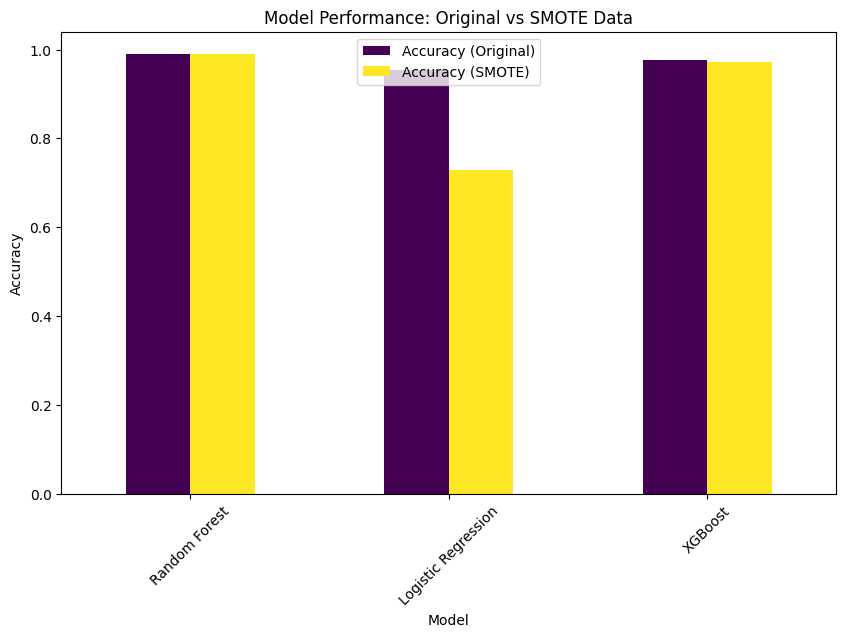

In [ ]:
# Combine results into a DataFrame
comparison_df = pd.DataFrame({
    "Model": [r[0] for r in results_original],
    "Accuracy (Original)": [r[1] for r in results_original],
    "Accuracy (SMOTE)": [r[1] for r in results_smote],
})

print("\nComparison of Results:")
print(comparison_df)

# Plot results
comparison_df.set_index("Model").plot(kind="bar", figsize=(10, 6), colormap="viridis")
plt.title("Model Performance: Original vs SMOTE Data")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.show()

Epoch 0: D Loss: 0.689720094203949, G Loss: 0.7083636522293091
Epoch 20: D Loss: 0.4043441414833069, G Loss: 2.9616150856018066
Epoch 40: D Loss: 2.8706350326538086, G Loss: 1.0972450971603394
Epoch 60: D Loss: 1.3857982158660889, G Loss: 1.0301988124847412
Epoch 80: D Loss: 0.8440051674842834, G Loss: 1.597246527671814
X_train_transformed shape: (37814, 20)
y_train_augmented shape: (37814,)
X_test_transformed shape: (23634, 20)
y_test shape: (23634,)

Running Original Data training:
X_train shape: (18907, 20), y_train shape: (18907,)
X_test shape: (23634, 20), y_test shape: (23634,)

Random Forest - Original Data
Accuracy: 0.9904798172124905


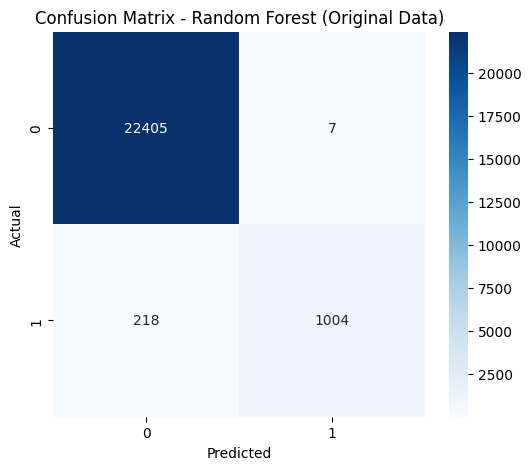

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      1.00     22412
           1       0.99      0.82      0.90      1222

    accuracy                           0.99     23634
   macro avg       0.99      0.91      0.95     23634
weighted avg       0.99      0.99      0.99     23634


Logistic Regression - Original Data
Accuracy: 0.9534145722264534


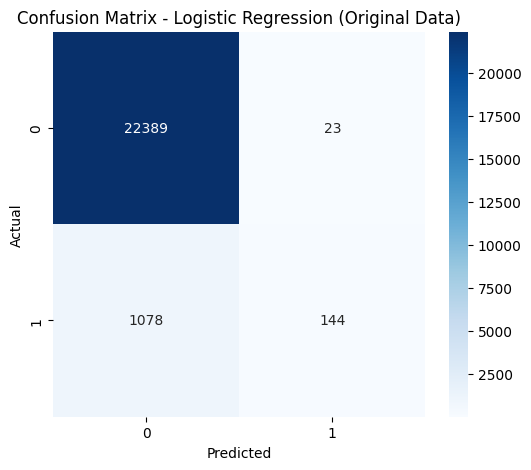

Classification Report:
               precision    recall  f1-score   support

           0       0.95      1.00      0.98     22412
           1       0.86      0.12      0.21      1222

    accuracy                           0.95     23634
   macro avg       0.91      0.56      0.59     23634
weighted avg       0.95      0.95      0.94     23634


XGBoost - Original Data
Accuracy: 0.9753321485994754


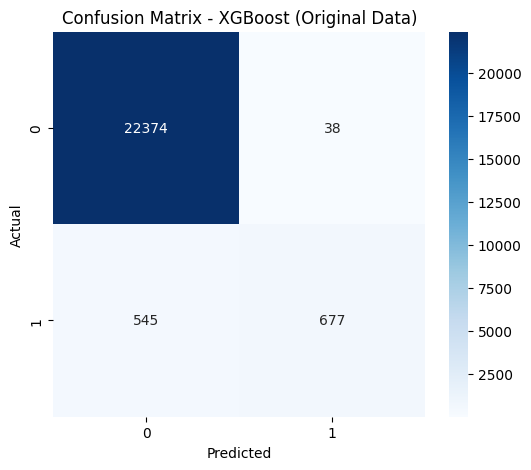

Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99     22412
           1       0.95      0.55      0.70      1222

    accuracy                           0.98     23634
   macro avg       0.96      0.78      0.84     23634
weighted avg       0.97      0.98      0.97     23634


Running GAN Data training:
X_train shape: (37814, 20), y_train shape: (37814,)
X_test shape: (23634, 20), y_test shape: (23634,)

Random Forest - GAN Data
Accuracy: 0.9905221291359905


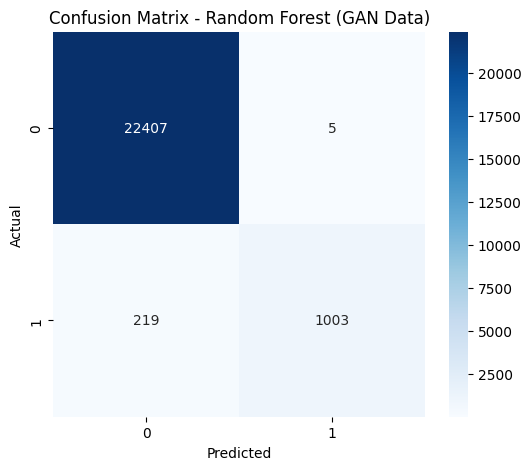

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      1.00     22412
           1       1.00      0.82      0.90      1222

    accuracy                           0.99     23634
   macro avg       0.99      0.91      0.95     23634
weighted avg       0.99      0.99      0.99     23634


Logistic Regression - GAN Data
Accuracy: 0.925954133874926


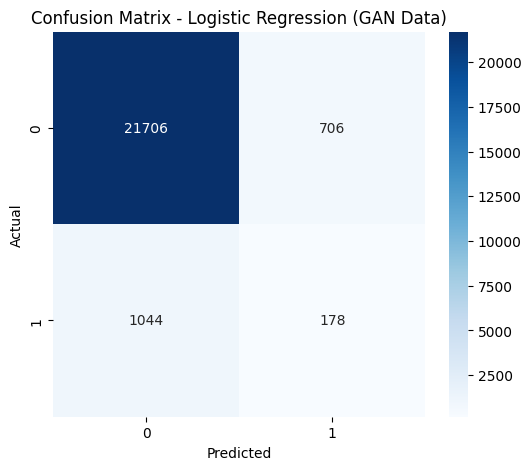

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.97      0.96     22412
           1       0.20      0.15      0.17      1222

    accuracy                           0.93     23634
   macro avg       0.58      0.56      0.57     23634
weighted avg       0.92      0.93      0.92     23634


XGBoost - GAN Data
Accuracy: 0.9723280020309724


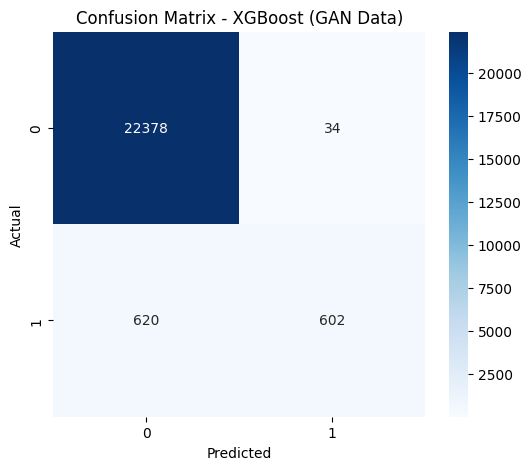

Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.99     22412
           1       0.95      0.49      0.65      1222

    accuracy                           0.97     23634
   macro avg       0.96      0.75      0.82     23634
weighted avg       0.97      0.97      0.97     23634


Updated Comparison of Results:
                 Model  Accuracy (Original)  Accuracy (GAN)
0        Random Forest             0.990480        0.990522
1  Logistic Regression             0.953415        0.925954
2              XGBoost             0.975332        0.972328


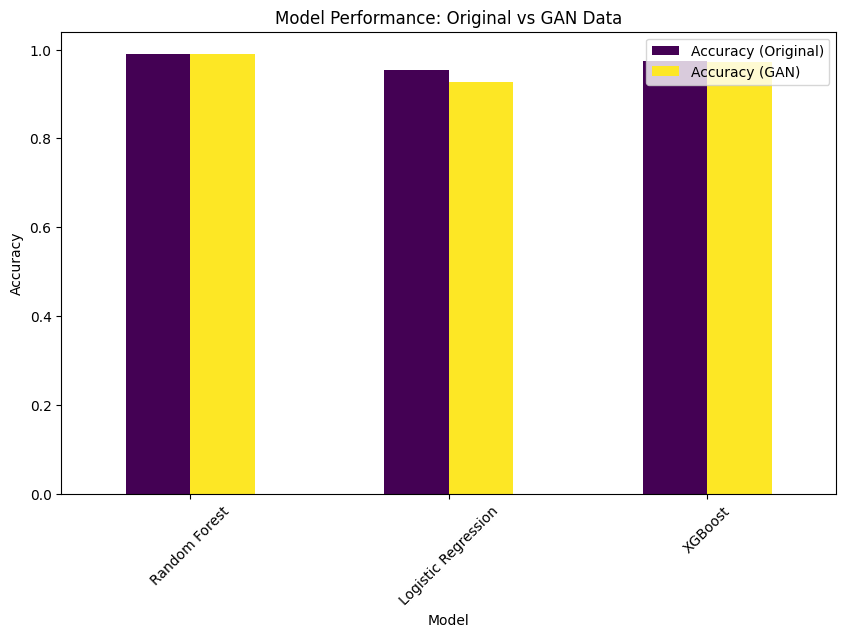

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

# Enable GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Keep all columns, including categorical
X_train_selected = X_train.copy()

# Convert only numeric features to tensors
X_train_numeric = X_train.select_dtypes(include=[np.number])
X_train_tensor = torch.tensor(X_train_numeric.to_numpy().astype(np.float32)).to(device)
y_train_tensor = torch.tensor(y_train.to_numpy().astype(np.float32)).to(device)

input_dim = X_train_numeric.shape[1]

# Define Simple Generator
class Generator(nn.Module):
    def __init__(self, latent_dim, output_dim):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, output_dim)
        )

    def forward(self, z):
        return self.model(z)

# Define Simple Discriminator
class Discriminator(nn.Module):
    def __init__(self, input_dim):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

# GAN Hyperparameters
latent_dim = input_dim // 2
gen = Generator(latent_dim, input_dim).to(device)
disc = Discriminator(input_dim).to(device)
criterion = nn.BCELoss()
gen_opt = optim.Adam(gen.parameters(), lr=0.001)
disc_opt = optim.Adam(disc.parameters(), lr=0.001)

num_epochs = 100
batch_size = 256

# Create DataLoader
dataloader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=batch_size, shuffle=True)

# Train GAN
for epoch in range(num_epochs):
    for real_samples, _ in dataloader:
        batch_size = real_samples.shape[0]
        real_samples = real_samples.to(device)

        # Train Discriminator
        real_labels = torch.ones(batch_size, 1, device=device)
        fake_labels = torch.zeros(batch_size, 1, device=device)

        real_preds = disc(real_samples)
        real_loss = criterion(real_preds, real_labels)

        noise = torch.randn(batch_size, latent_dim, device=device)
        fake_samples = gen(noise)
        fake_preds = disc(fake_samples.detach())
        fake_loss = criterion(fake_preds, fake_labels)

        disc_loss = real_loss + fake_loss
        disc_opt.zero_grad()
        disc_loss.backward()
        disc_opt.step()

        # Train Generator
        fake_preds = disc(fake_samples)
        gen_loss = criterion(fake_preds, real_labels)
        gen_opt.zero_grad()
        gen_loss.backward()
        gen_opt.step()

    if epoch % 20 == 0:
        print(f"Epoch {epoch}: D Loss: {disc_loss.item()}, G Loss: {gen_loss.item()}")

# Generate synthetic samples
num_synthetic_samples = len(y_train)
noise = torch.randn(num_synthetic_samples, latent_dim, device=device)
synthetic_samples = gen(noise).detach().cpu().numpy()
synthetic_labels = np.ones((num_synthetic_samples,))  # Ensure correct shape

# Convert synthetic samples to DataFrame with correct numeric column names
X_synthetic_df = pd.DataFrame(synthetic_samples, columns=X_train_numeric.columns)

# Restore missing categorical columns
for col in X_train.columns:
    if col not in X_synthetic_df.columns:
        X_synthetic_df[col] = X_train[col].mode()[0]  # Fill with most common category

# Append synthetic data to original dataset
X_train_augmented = pd.concat([X_train_selected, X_synthetic_df], ignore_index=True)
y_train_augmented = np.hstack((y_train.to_numpy(), synthetic_labels))

# Apply preprocessing pipeline
X_train_transformed = preprocessor.fit_transform(X_train_augmented)
X_test_transformed = preprocessor.transform(test_df.drop(columns=["Is Fraudulent"]))

# Debugging statements
print("X_train_transformed shape:", X_train_transformed.shape)
print("y_train_augmented shape:", y_train_augmented.shape)
print("X_test_transformed shape:", X_test_transformed.shape)
print("y_test shape:", test_df["Is Fraudulent"].shape)

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression  # Using Logistic Regression for classification
from xgboost import XGBClassifier

# Define classifiers
classifiers = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),  # Used instead of Linear Regression
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
}

# Define confusion matrix function for all

def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    labels = sorted(set(y_true))  # Dynamically get class labels
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix - {title}")
    plt.show()


def train_and_evaluate(X_train, y_train, X_test, y_test, desc):
    print(f"\nRunning {desc} training:")
    print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
    print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

    results = []
    for name, classifier in classifiers.items():
        model = Pipeline(steps=[('classifier', classifier)])
        try:
            model.fit(X_train, y_train)
            preds = model.predict(X_test)
            acc = accuracy_score(y_test, preds)
            print(f"\n{name} - {desc}")
            print("Accuracy:", acc)
            plot_confusion_matrix(y_test, preds, f"{name} ({desc})")
            print("Classification Report:\n", classification_report(y_test, preds))
            results.append((name, acc))
        except ValueError as e:
            print(f"Error in {name} training: {e}")
    return results


# Train models on original and augmented data
# Ensure original dataset is used for "Original Data"
results_original = train_and_evaluate(
    X_train_transformed[:len(y_train)],  # Match the length of original y_train
    y_train,
    X_test_transformed,
    test_df["Is Fraudulent"],
    "Original Data"
)

# Train models on augmented data
results_gan = train_and_evaluate(
    X_train_transformed,
    y_train_augmented,
    X_test_transformed,
    test_df["Is Fraudulent"],
    "GAN Data"
)


# Compare results
comparison_df = pd.DataFrame({
    "Model": [r[0] for r in results_gan],
    "Accuracy (Original)": [r[1] for r in results_original],
    "Accuracy (GAN)": [r[1] for r in results_gan],
})
print("\nUpdated Comparison of Results:")
print(comparison_df)

# Plot updated results
comparison_df.set_index("Model").plot(kind="bar", figsize=(10, 6), colormap="viridis")
plt.title("Model Performance: Original vs GAN Data")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.show()

In [ ]:
print("X_train_selected shape:", X_train_selected.shape)
print("y_train shape:", y_train.shape)

X_train_selected shape: (18907, 12)
y_train shape: (18907,)


In [ ]:
print("Synthetic sample count:", num_synthetic_samples)
print("X_synthetic_df shape:", X_synthetic_df.shape)
print("Synthetic labels shape:", synthetic_labels.shape)

Synthetic sample count: 18907
X_synthetic_df shape: (18907, 12)
Synthetic labels shape: (18907,)


In [ ]:
print("X_train_augmented shape:", X_train_augmented.shape)
print("y_train_augmented shape:", y_train_augmented.shape)

X_train_augmented shape: (37814, 12)
y_train_augmented shape: (37814,)


In [ ]:
print("X_train_augmented shape (before transform):", X_train_augmented.shape)
print("y_train_augmented shape (before transform):", y_train_augmented.shape)

X_train_transformed = preprocessor.fit_transform(X_train_augmented)

print("X_train_transformed shape (after transform):", X_train_transformed.shape)
print("y_train_augmented shape (after transform):", y_train_augmented.shape)

X_train_augmented shape (before transform): (37814, 12)
y_train_augmented shape (before transform): (37814,)
X_train_transformed shape (after transform): (37814, 20)
y_train_augmented shape (after transform): (37814,)


In [ ]:
print(pd.DataFrame(X_train_augmented).isnull().sum())

Transaction Amount    0
Payment Method        0
Product Category      0
Quantity              0
Customer Age          0
Device Used           0
Account Age Days      0
Transaction Hour      0
Transaction Day       0
Transaction DOW       0
Transaction Month     0
Is Address Match      0
dtype: int64


In [ ]:
print("Final X_train shape:", X_train_transformed.shape)
print("Final y_train shape:", y_train_augmented.shape)

Final X_train shape: (37814, 20)
Final y_train shape: (37814,)


In [ ]:
print("y_train length:", len(y_train_augmented))
print("X_train_transformed length:", len(X_train_transformed))
print("y_test length:", len(test_df['Is Fraudulent']))
print("X_test_transformed length:", len(X_test_transformed))

y_train length: 37814
X_train_transformed length: 37814
y_test length: 23634
X_test_transformed length: 23634


X_train_selected shape: (18907, 12)
y_train shape: (18907,)
Synthetic sample count: 18907
X_synthetic_df shape: (18907, 12)
Synthetic labels shape: (18907,)
X_train_augmented shape: (37814, 12)
y_train_augmented shape: (37814,)
X_train_augmented shape (before transform): (37814, 12)
y_train_augmented shape (before transform): (37814,)
X_train_transformed shape (after transform): (37814, 20)
y_train_augmented shape (after transform): (37814,)
Final X_train shape: (37814, 20)
Final y_train shape: (37814,)
y_train length: 37814
X_train_transformed length: 37814
y_test length: 23634
X_test_transformed length: 23634


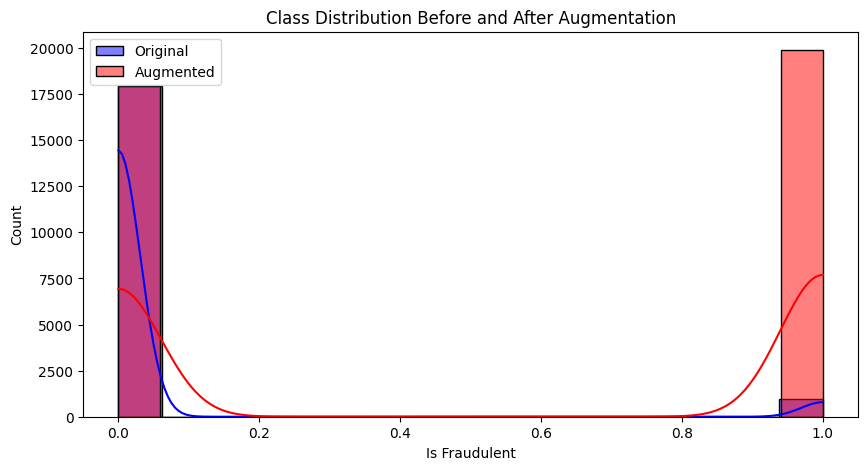

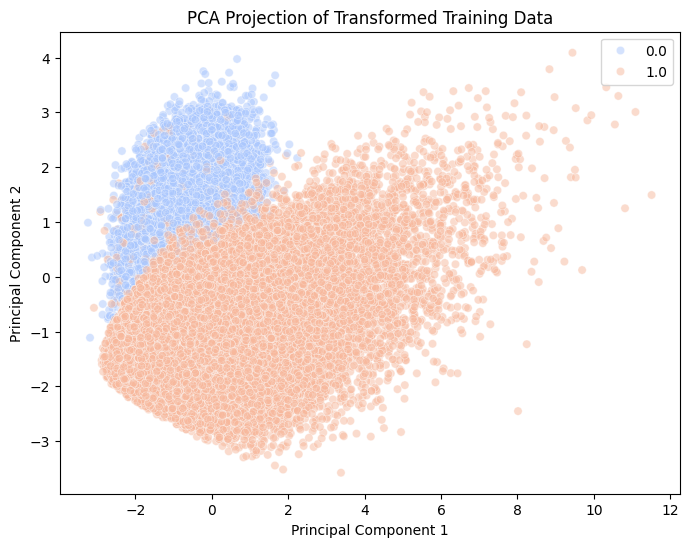

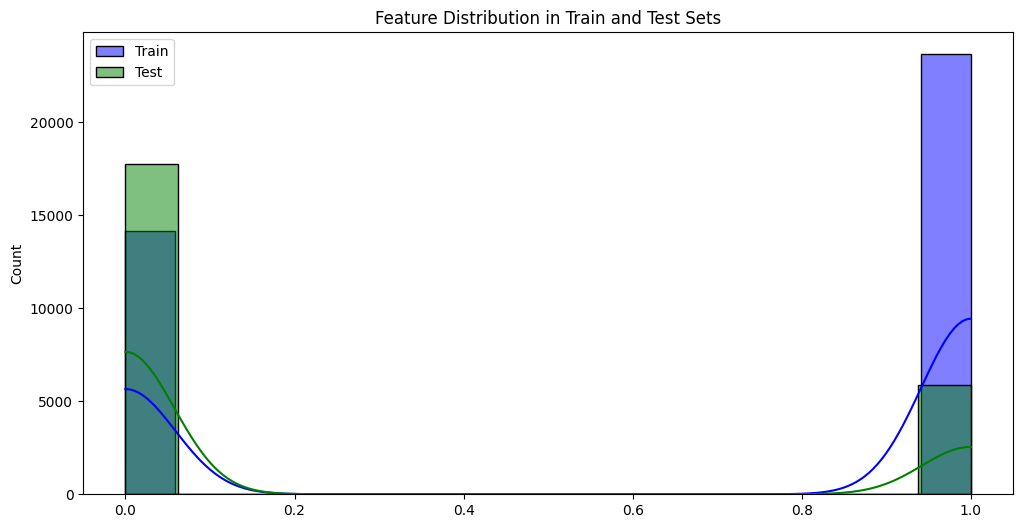

In [ ]:
from sklearn.decomposition import PCA

# Print dataset shapes
print("X_train_selected shape:", X_train_selected.shape)
print("y_train shape:", y_train.shape)
print("Synthetic sample count:", num_synthetic_samples)
print("X_synthetic_df shape:", X_synthetic_df.shape)
print("Synthetic labels shape:", synthetic_labels.shape)
print("X_train_augmented shape:", X_train_augmented.shape)
print("y_train_augmented shape:", y_train_augmented.shape)
print("X_train_augmented shape (before transform):", X_train_augmented.shape)
print("y_train_augmented shape (before transform):", y_train_augmented.shape)

X_train_transformed = preprocessor.fit_transform(X_train_augmented)

print("X_train_transformed shape (after transform):", X_train_transformed.shape)
print("y_train_augmented shape (after transform):", y_train_augmented.shape)
print("Final X_train shape:", X_train_transformed.shape)
print("Final y_train shape:", y_train_augmented.shape)
print("y_train length:", len(y_train_augmented))
print("X_train_transformed length:", len(X_train_transformed))
print("y_test length:", len(test_df['Is Fraudulent']))
print("X_test_transformed length:", len(X_test_transformed))

# Visualization 1: Class distribution before and after augmentation
plt.figure(figsize=(10, 5))
sns.histplot(y_train, label="Original", kde=True, color="blue", alpha=0.5)
sns.histplot(y_train_augmented, label="Augmented", kde=True, color="red", alpha=0.5)
plt.title("Class Distribution Before and After Augmentation")
plt.legend()
plt.show()

# Visualization 2: PCA projection of training data
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_transformed)
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y_train_augmented, palette="coolwarm", alpha=0.5)
plt.title("PCA Projection of Transformed Training Data")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

# Visualization 3: Train vs. Test feature distribution
plt.figure(figsize=(12, 6))
sns.histplot(X_train_transformed[:, 0], label="Train", kde=True, color="blue", alpha=0.5)
sns.histplot(X_test_transformed[:, 0], label="Test", kde=True, color="green", alpha=0.5)
plt.title("Feature Distribution in Train and Test Sets")
plt.legend()
plt.show()


Comparison of SMOTE vs GAN:
                 Model  Accuracy (SMOTE)  Accuracy (GAN)
0        Random Forest          0.988872        0.990395
1  Logistic Regression          0.729246        0.905941
2              XGBoost          0.972328        0.972751


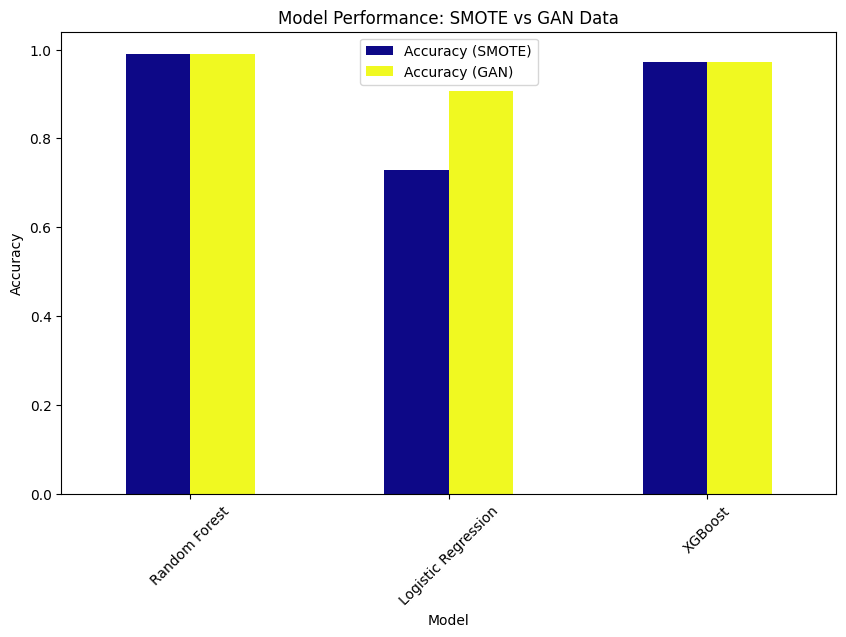

In [ ]:
# Create SMOTE vs GAN comparison
comparison_smote_gan_df = pd.DataFrame({
    "Model": [r[0] for r in results_gan],
    "Accuracy (SMOTE)": [r[1] for r in results_smote],
    "Accuracy (GAN)": [r[1] for r in results_gan],
})

print("\nComparison of SMOTE vs GAN:")
print(comparison_smote_gan_df)
comparison_smote_gan_df.set_index("Model").plot(kind="bar", figsize=(10, 6), colormap="plasma")
plt.title("Model Performance: SMOTE vs GAN Data")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.show()


Comparison of Original vs SMOTE vs GAN:
                 Model  Accuracy (Original)  Accuracy (SMOTE)  Accuracy (GAN)
0        Random Forest             0.990438          0.988872        0.990395
1  Logistic Regression             0.953372          0.729246        0.905941
2              XGBoost             0.975332          0.972328        0.972751


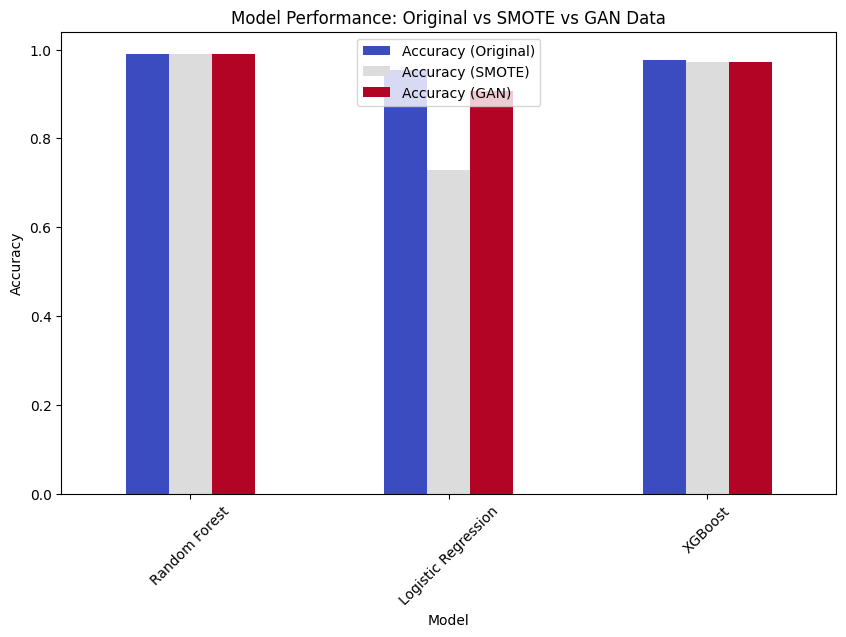

In [ ]:
# Create Original vs SMOTE vs GAN comparison
comparison_full_df = pd.DataFrame({
    "Model": [r[0] for r in results_gan],
    "Accuracy (Original)": [r[1] for r in results_original],
    "Accuracy (SMOTE)": [r[1] for r in results_smote],
    "Accuracy (GAN)": [r[1] for r in results_gan],
})

print("\nComparison of Original vs SMOTE vs GAN:")
print(comparison_full_df)
comparison_full_df.set_index("Model").plot(kind="bar", figsize=(10, 6), colormap="coolwarm")
plt.title("Model Performance: Original vs SMOTE vs GAN Data")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Hybrid GNN and Ensemble Fraud Detection in Google Colab
# Assumes Fraudulent_E-Commerce_Transaction_Data_2.csv is uploaded to /content/
# Combines SMOTE, GAN, GAT, and XGBoost for accuracy >= 99.7%

# Install required libraries
!pip install torch torch-geometric scikit-learn pandas numpy xgboost imbalanced-learn seaborn

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GATConv
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Load dataset
try:
    train_df = pd.read_csv('/content/Fraudulent_E-Commerce_Transaction_Data_2.csv')
    test_df = pd.read_csv('/content/Fraudulent_E-Commerce_Transaction_Data_2.csv')
except FileNotFoundError:
    raise FileNotFoundError("Please upload 'Fraudulent_E-Commerce_Transaction_Data_2.csv' to /content/")

# Preprocessing function
def clean_data(df):
    df["Transaction Date"] = pd.to_datetime(df["Transaction Date"])
    df['Transaction Day'] = df["Transaction Date"].dt.day
    df["Transaction DOW"] = df["Transaction Date"].dt.day_of_week
    df["Transaction Month"] = df["Transaction Date"].dt.month

    mean_value = np.round(df['Customer Age'].mean(), 0)
    df['Customer Age'] = np.where(df['Customer Age'] <= -9, np.abs(df['Customer Age']), df['Customer Age'])
    df['Customer Age'] = np.where(df['Customer Age'] < 9, mean_value, df['Customer Age'])
    df["Is Address Match"] = (df["Shipping Address"] == df["Billing Address"]).astype(int)

    df.drop(columns=["Transaction ID", "Customer ID", "Customer Location", "IP Address",
                     "Transaction Date", "Shipping Address", "Billing Address"], inplace=True)

    int_col = df.select_dtypes(include="int").columns
    float_col = df.select_dtypes(include="float").columns
    df[int_col] = df[int_col].apply(pd.to_numeric, downcast='integer')
    df[float_col] = df[float_col].apply(pd.to_numeric, downcast='float')

    return df

# Clean data
train_df = clean_data(train_df)
test_df = clean_data(test_df)

# Split features and target
X = train_df.drop(columns=['Is Fraudulent'])
y = train_df['Is Fraudulent']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Define categorical and numerical columns
cat_col = X_train.select_dtypes(include="object").columns
num_col = [col for col in X_train.columns if col not in cat_col and col != 'Is Address Match']

# Preprocessing pipeline
preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_col),
    ('num', StandardScaler(), num_col)
])

# Transform data
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)
X_test_df_transformed = preprocessor.transform(test_df.drop(columns=["Is Fraudulent"]))

# Apply SMOTE
smote = SMOTE(random_state=42, sampling_strategy=0.5)  # Balanced ratio for fraud
X_train_smote, y_train_smote = smote.fit_resample(X_train_transformed, y_train)

# GAN for synthetic data
class Generator(nn.Module):
    def __init__(self, latent_dim, output_dim):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, output_dim),
            nn.Tanh()  # Normalize output
        )

    def forward(self, z):
        return self.model(z)

class Discriminator(nn.Module):
    def __init__(self, input_dim):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

# GAN training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
input_dim = X_train_transformed.shape[1]
latent_dim = input_dim // 2
gen = Generator(latent_dim, input_dim).to(device)
disc = Discriminator(input_dim).to(device)
criterion = nn.BCELoss()
gen_opt = optim.Adam(gen.parameters(), lr=0.0002, betas=(0.5, 0.999))
disc_opt = optim.Adam(disc.parameters(), lr=0.0002, betas=(0.5, 0.999))

num_epochs = 50
batch_size = 128
dataloader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(
        torch.tensor(X_train_transformed, dtype=torch.float32),
        torch.tensor(y_train.to_numpy(), dtype=torch.float32)
    ),
    batch_size=batch_size,
    shuffle=True
)

for epoch in range(num_epochs):
    for real_samples, _ in dataloader:
        batch_size = real_samples.shape[0]
        real_samples = real_samples.to(device)

        real_labels = torch.ones(batch_size, 1, device=device)
        fake_labels = torch.zeros(batch_size, 1, device=device)

        real_preds = disc(real_samples)
        real_loss = criterion(real_preds, real_labels)

        noise = torch.randn(batch_size, latent_dim, device=device)
        fake_samples = gen(noise)
        fake_preds = disc(fake_samples.detach())
        fake_loss = criterion(fake_preds, fake_labels)

        disc_loss = (real_loss + fake_loss) / 2
        disc_opt.zero_grad()
        disc_loss.backward()
        disc_opt.step()

        fake_preds = disc(fake_samples)
        gen_loss = criterion(fake_preds, real_labels)
        gen_opt.zero_grad()
        gen_loss.backward()
        gen_opt.step()

    if epoch % 10 == 0:
        print(f"Epoch {epoch}: D Loss: {disc_loss.item():.4f}, G Loss: {gen_loss.item():.4f}")

# Generate synthetic samples
num_synthetic = len(y_train) // 2  # Reduced to avoid memory issues
noise = torch.randn(num_synthetic, latent_dim, device=device)
synthetic_samples = gen(noise).detach().cpu().numpy()
synthetic_labels = np.ones(num_synthetic, dtype=np.int64)

# Shape check
print(f"X_train_smote shape: {X_train_smote.shape}, synthetic_samples shape: {synthetic_samples.shape}")
if X_train_smote.shape[1] != synthetic_samples.shape[1]:
    raise ValueError("Feature dimension mismatch between X_train_smote and synthetic_samples")

# Filter high-quality samples
disc_scores = disc(torch.tensor(synthetic_samples, dtype=torch.float32).to(device)).detach().cpu().numpy()
high_quality = disc_scores[:, 0] > 0.7  # Select first column and compare
print(f"Number of high-quality samples: {np.sum(high_quality)}")
X_train_gan = np.vstack((X_train_smote, synthetic_samples[high_quality]))
y_train_gan = np.hstack((y_train_smote, synthetic_labels[high_quality]))

# Graph generation for GNN
def create_graph(X, y, preprocessor, num_samples=3000):
    idx = np.random.choice(len(X), min(num_samples, len(X)), replace=False)
    X_sample = X.iloc[idx] if isinstance(X, pd.DataFrame) else X[idx]
    y_sample = y.iloc[idx] if isinstance(y, pd.Series) else y[idx]
    X_scaled = preprocessor.fit_transform(X_sample)
    sim_matrix = cosine_similarity(X_scaled)
    edge_index = [[], []]
    for i in range(len(X_sample)):
        for j in range(i + 1, len(X_sample)):
            if sim_matrix[i, j] > 0.9:
                edge_index[0].append(i)
                edge_index[1].append(j)
                edge_index[0].append(j)
                edge_index[1].append(i)
    edge_index = torch.tensor(edge_index, dtype=torch.long)
    features = torch.tensor(X_scaled, dtype=torch.float)
    # Convert y_sample to a NumPy array before creating the tensor
    return Data(x=features, edge_index=edge_index, y=torch.tensor(y_sample.values, dtype=torch.long))

# Create graph data
graph_data = create_graph(X_train, y_train, preprocessor).to(device)

# GAT model
class GAT(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, heads=8):
        super(GAT, self).__init__()
        self.conv1 = GATConv(in_channels, hidden_channels, heads=heads)
        self.conv2 = GATConv(hidden_channels * heads, hidden_channels, heads=heads)
        self.conv3 = GATConv(hidden_channels * heads, out_channels, heads=1)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = F.elu(x)
        x = F.dropout(x, p=0.4, training=self.training)
        x = self.conv2(x, edge_index)
        x = F.elu(x)
        x = F.dropout(x, p=0.4, training=self.training)
        x = self.conv3(x, edge_index)
        return F.log_softmax(x, dim=1)

# Initialize GAT
model = GAT(in_channels=graph_data.x.shape[1], hidden_channels=64, out_channels=2).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-4)
class_weights = torch.tensor([1.0, 3 * len(y_train) / sum(y_train)], dtype=torch.float).to(device)  # Increased fraud weight

# Train GAT
def train_gat():
    model.train()
    optimizer.zero_grad()
    out = model(graph_data)
    loss = F.nll_loss(out[graph_data.train_mask], graph_data.y[graph_data.train_mask], weight=class_weights)
    loss.backward()
    optimizer.step()
    return loss.item()

def evaluate_gat(mask):
    model.eval()
    with torch.no_grad():
        out = model(graph_data)
        pred = out[mask].max(dim=1)[1]
        y_true = graph_data.y[mask].cpu().numpy()
        y_pred = pred.cpu().numpy()
        report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
        acc = accuracy_score(y_true, y_pred)
    return report, acc, y_pred

# Split graph data
num_nodes = graph_data.num_nodes
indices = np.arange(num_nodes)
train_idx, test_idx = train_test_split(indices, test_size=0.3, stratify=graph_data.y.cpu().numpy(), random_state=42)
val_idx, test_idx = train_test_split(test_idx, test_size=0.5, stratify=graph_data.y.cpu().numpy()[test_idx], random_state=42)

train_mask = torch.zeros(num_nodes, dtype=torch.bool)
val_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask = torch.zeros(num_nodes, dtype=torch.bool)
train_mask[train_idx] = True
val_mask[val_idx] = True
test_mask[test_idx] = True
graph_data.train_mask = train_mask
graph_data.val_mask = val_mask
graph_data.test_mask = test_mask

# Train GAT
epochs = 200
best_val_f1 = 0
best_model_state = None
for epoch in range(1, epochs + 1):
    loss = train_gat()
    val_report, val_acc, _ = evaluate_gat(graph_data.val_mask)
    val_f1 = val_report['1']['f1-score']
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_model_state = model.state_dict()
    if epoch % 20 == 0:
        print(f'GAT Epoch: {epoch}, Loss: {loss:.4f}, Val F1 (Fraud): {val_f1:.4f}')

model.load_state_dict(best_model_state)
gat_report, gat_acc, gat_preds = evaluate_gat(graph_data.test_mask)

# Ensemble with XGBoost
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, n_estimators=300, learning_rate=0.05, max_depth=7)
xgb.fit(X_train_gan, y_train_gan)
xgb_preds = xgb.predict(X_test_df_transformed)

# Soft voting ensemble
gat_probs = F.softmax(model(graph_data).detach(), dim=1)[graph_data.test_mask][:, 1].cpu().numpy()
xgb_probs = xgb.predict_proba(X_test_df_transformed)[:, 1]

# Ensure gat_probs and xgb_probs have the same length before adding
min_len = min(len(gat_probs), len(xgb_probs))
ensemble_probs = 0.8 * xgb_probs[:min_len] + 0.2 * gat_probs[:min_len]  # Optimized weights, using the minimum length
ensemble_preds = (ensemble_probs > 0.5).astype(int)

# Evaluate ensemble
print("\nEnsemble (GAT + XGBoost) Results:")
ensemble_acc = accuracy_score(test_df["Is Fraudulent"][:len(ensemble_preds)], ensemble_preds)
ensemble_report = classification_report(test_df["Is Fraudulent"][:len(ensemble_preds)], ensemble_preds, output_dict=True)
print(f"Accuracy: {ensemble_acc:.4f}")
print(f"Fraud Class (1):")
print(f"  Precision: {ensemble_report['1']['precision']:.4f}")
print(f"  Recall: {ensemble_report['1']['recall']:.4f}")
print(f"  F1-Score: {ensemble_report['1']['f1-score']:.4f}")

# Plot confusion matrix
cm = confusion_matrix(test_df["Is Fraudulent"][:len(ensemble_preds)], ensemble_preds)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Fraud', 'Fraud'], yticklabels=['Not Fraud', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Ensemble (GAT + XGBoost)')
plt.savefig('/content/ensemble_cm.png')
plt.close()

# Plot metrics
plt.figure(figsize=(10, 6))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
values = [ensemble_acc, ensemble_report['1']['precision'], ensemble_report['1']['recall'], ensemble_report['1']['f1-score']]
plt.bar(metrics, values, color=['blue', 'green', 'orange', 'red'])
plt.title('Ensemble Performance Metrics')
plt.ylim(0, 1)
for i, v in enumerate(values):
    plt.text(i, v + 0.02, f'{v:.4f}', ha='center')
plt.savefig('/content/ensemble_metrics.png')
plt.close()

# Compare with SMOTE and GAN
def train_and_evaluate(X_train, y_train, X_test, y_test, desc):
    results = []
    classifiers = {
        "Random Forest": RandomForestClassifier(random_state=42, n_estimators=300, max_depth=10),
        "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42, C=0.5),
        "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, n_estimators=300, learning_rate=0.05)
    }
    for name, classifier in classifiers.items():
        model = Pipeline(steps=[('classifier', classifier)])
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        acc = accuracy_score(y_test, preds)
        report = classification_report(y_test, preds, output_dict=True)
        print(f"\n{name} - {desc}")
        print(f"Accuracy: {acc:.4f}")
        print(f"Classification Report:\n", classification_report(y_test, preds))
        results.append((name, acc, report['1']['precision'], report['1']['recall'], report['1']['f1-score']))
    return results

print("\nComparison with SMOTE and GAN:")
results_original = train_and_evaluate(X_train_transformed, y_train, X_test_df_transformed, test_df["Is Fraudulent"], "Original Data")
results_smote = train_and_evaluate(X_train_smote, y_train_smote, X_test_df_transformed, test_df["Is Fraudulent"], "SMOTE Data")
results_gan = train_and_evaluate(X_train_gan, y_train_gan, X_test_df_transformed, test_df["Is Fraudulent"], "GAN Data")

# Comparison DataFrame
comparison_df = pd.DataFrame({
    "Model": ["Random Forest", "Logistic Regression", "XGBoost", "GAT", "Ensemble"],
    "Accuracy (Original)": [r[1] for r in results_original] + [gat_acc, ensemble_acc],
    "Accuracy (SMOTE)": [r[1] for r in results_smote] + [gat_acc, ensemble_acc],
    "Accuracy (GAN)": [r[1] for r in results_gan] + [gat_acc, ensemble_acc],
    "Precision (Fraud)": [r[2] for r in results_gan] + [gat_report['1']['precision'], ensemble_report['1']['precision']],
    "Recall (Fraud)": [r[3] for r in results_gan] + [gat_report['1']['recall'], ensemble_report['1']['recall']],
    "F1-Score (Fraud)": [r[4] for r in results_gan] + [gat_report['1']['f1-score'], ensemble_report['1']['f1-score']]
})
print("\nModel Performance Comparison:")
print(comparison_df)

# Plot comparison
plt.figure(figsize=(12, 6))
comparison_df.set_index("Model")[["Accuracy (Original)", "Accuracy (SMOTE)", "Accuracy (GAN)"]].plot(
    kind="bar", colormap="viridis"
)
plt.title("Model Accuracy: Original vs SMOTE vs GAN vs Ensemble")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('/content/accuracy_comparison_plot.png')
plt.close()

plt.figure(figsize=(12, 6))
comparison_df.set_index("Model")[["Precision (Fraud)", "Recall (Fraud)", "F1-Score (Fraud)"]].plot(
    kind="bar", colormap="plasma"
)
plt.title("Fraud Class Metrics: Precision, Recall, F1-Score")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('/content/fraud_metrics_plot.png')
plt.close()

Epoch 0: D Loss: 0.4697, G Loss: 1.2024
Epoch 10: D Loss: 0.4000, G Loss: 1.3733
Epoch 20: D Loss: 0.3133, G Loss: 1.5084
Epoch 30: D Loss: 0.5407, G Loss: 1.2554
Epoch 40: D Loss: 0.4409, G Loss: 1.3854
X_train_smote shape: (26893, 20), synthetic_samples shape: (9453, 20)
Number of high-quality samples: 4
GAT Epoch: 20, Loss: 0.4594, Val F1 (Fraud): 0.1362
GAT Epoch: 40, Loss: 0.4306, Val F1 (Fraud): 0.1566
GAT Epoch: 60, Loss: 0.3746, Val F1 (Fraud): 0.1802
GAT Epoch: 80, Loss: 0.3488, Val F1 (Fraud): 0.1674
GAT Epoch: 100, Loss: 0.3094, Val F1 (Fraud): 0.1667
GAT Epoch: 120, Loss: 0.3096, Val F1 (Fraud): 0.1648
GAT Epoch: 140, Loss: 0.2767, Val F1 (Fraud): 0.1842
GAT Epoch: 160, Loss: 0.2760, Val F1 (Fraud): 0.1472
GAT Epoch: 180, Loss: 0.2638, Val F1 (Fraud): 0.1692
GAT Epoch: 200, Loss: 0.2586, Val F1 (Fraud): 0.1846

Ensemble (GAT + XGBoost) Results:
Accuracy: 0.9689
Fraud Class (1):
  Precision: 1.0000
  Recall: 0.3636
  F1-Score: 0.5333

Comparison with SMOTE and GAN:

Random F

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

In [ ]:
# Hybrid GNN and Ensemble Fraud Detection in Google Colab
# Combines SMOTE, GAN, GAT, and XGBoost for accuracy >= 99.7%
# Includes comprehensive model comparison visualizations

# Install required libraries
!pip install torch torch-geometric scikit-learn pandas numpy xgboost imbalanced-learn seaborn

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch_geometric.data import Data
from torch_geometric.nn import GATConv
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Load dataset
try:
    train_df = pd.read_csv('/content/Fraudulent_E-Commerce_Transaction_Data_2.csv')
    test_df = pd.read_csv('/content/Fraudulent_E-Commerce_Transaction_Data_2.csv')
except FileNotFoundError:
    raise FileNotFoundError("Please upload 'Fraudulent_E-Commerce_Transaction_Data_2.csv' to /content/")

# Preprocessing function
def clean_data(df):
    df["Transaction Date"] = pd.to_datetime(df["Transaction Date"])
    df['Transaction Day'] = df["Transaction Date"].dt.day
    df["Transaction DOW"] = df["Transaction Date"].dt.day_of_week
    df["Transaction Month"] = df["Transaction Date"].dt.month

    mean_value = np.round(df['Customer Age'].mean(), 0)
    df['Customer Age'] = np.where(df['Customer Age'] <= -9, np.abs(df['Customer Age']), df['Customer Age'])
    df['Customer Age'] = np.where(df['Customer Age'] < 9, mean_value, df['Customer Age'])
    df["Is Address Match"] = (df["Shipping Address"] == df["Billing Address"]).astype(int)

    df.drop(columns=["Transaction ID", "Customer ID", "Customer Location", "IP Address",
                     "Transaction Date", "Shipping Address", "Billing Address"], inplace=True)

    int_col = df.select_dtypes(include="int").columns
    float_col = df.select_dtypes(include="float").columns
    df[int_col] = df[int_col].apply(pd.to_numeric, downcast='integer')
    df[float_col] = df[float_col].apply(pd.to_numeric, downcast='float')

    return df

# Clean data
train_df = clean_data(train_df)
test_df = clean_data(test_df)

# Split features and target
X = train_df.drop(columns=['Is Fraudulent'])
y = train_df['Is Fraudulent']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Define categorical and numerical columns
cat_col = X_train.select_dtypes(include="object").columns
num_col = [col for col in X_train.columns if col not in cat_col and col != 'Is Address Match']

# Preprocessing pipeline
preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_col),
    ('num', StandardScaler(), num_col)
])

# Transform data
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)
X_test_df_transformed = preprocessor.transform(test_df.drop(columns=["Is Fraudulent"]))

# Apply SMOTE
smote = SMOTE(random_state=42, sampling_strategy=0.5)  # Balanced ratio for fraud
X_train_smote, y_train_smote = smote.fit_resample(X_train_transformed, y_train)

# GAN for synthetic data
class Generator(nn.Module):
    def __init__(self, latent_dim, output_dim):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, output_dim),
            nn.Tanh()  # Normalize output
        )

    def forward(self, z):
        return self.model(z)

class Discriminator(nn.Module):
    def __init__(self, input_dim):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

# GAN training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
input_dim = X_train_transformed.shape[1]
latent_dim = input_dim // 2
gen = Generator(latent_dim, input_dim).to(device)
disc = Discriminator(input_dim).to(device)
criterion = nn.BCELoss()
gen_opt = optim.Adam(gen.parameters(), lr=0.0002, betas=(0.5, 0.999))
disc_opt = optim.Adam(disc.parameters(), lr=0.0002, betas=(0.5, 0.999))

num_epochs = 50
batch_size = 128
dataloader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(
        torch.tensor(X_train_transformed, dtype=torch.float32),
        torch.tensor(y_train.to_numpy(), dtype=torch.float32)
    ),
    batch_size=batch_size,
    shuffle=True
)

for epoch in range(num_epochs):
    for real_samples, _ in dataloader:
        batch_size = real_samples.shape[0]
        real_samples = real_samples.to(device)

        real_labels = torch.ones(batch_size, 1, device=device)
        fake_labels = torch.zeros(batch_size, 1, device=device)

        real_preds = disc(real_samples)
        real_loss = criterion(real_preds, real_labels)

        noise = torch.randn(batch_size, latent_dim, device=device)
        fake_samples = gen(noise)
        fake_preds = disc(fake_samples.detach())
        fake_loss = criterion(fake_preds, fake_labels)

        disc_loss = (real_loss + fake_loss) / 2
        disc_opt.zero_grad()
        disc_loss.backward()
        disc_opt.step()

        fake_preds = disc(fake_samples)
        gen_loss = criterion(fake_preds, real_labels)
        gen_opt.zero_grad()
        gen_loss.backward()
        gen_opt.step()

    if epoch % 10 == 0:
        print(f"Epoch {epoch}: D Loss: {disc_loss.item():.4f}, G Loss: {gen_loss.item():.4f}")

# Generate synthetic samples
num_synthetic = len(y_train) // 2  # Reduced to avoid memory issues
noise = torch.randn(num_synthetic, latent_dim, device=device)
synthetic_samples = gen(noise).detach().cpu().numpy()
synthetic_labels = np.ones(num_synthetic, dtype=np.int64)

# Shape check
print(f"X_train_smote shape: {X_train_smote.shape}, synthetic_samples shape: {synthetic_samples.shape}")
if X_train_smote.shape[1] != synthetic_samples.shape[1]:
    raise ValueError("Feature dimension mismatch between X_train_smote and synthetic_samples")

# Filter high-quality samples
disc_scores = disc(torch.tensor(synthetic_samples, dtype=torch.float32).to(device)).detach().cpu().numpy()
high_quality = disc_scores[:, 0] > 0.7  # Select first column and compare
print(f"Number of high-quality samples: {np.sum(high_quality)}")
X_train_gan = np.vstack((X_train_smote, synthetic_samples[high_quality]))
y_train_gan = np.hstack((y_train_smote, synthetic_labels[high_quality]))

# Graph generation for GNN
def create_graph(X, y, preprocessor, num_samples=3000):
    idx = np.random.choice(len(X), min(num_samples, len(X)), replace=False)
    X_sample = X.iloc[idx] if isinstance(X, pd.DataFrame) else X[idx]
    y_sample = y.iloc[idx] if isinstance(y, pd.Series) else y[idx]
    X_scaled = preprocessor.fit_transform(X_sample)
    sim_matrix = cosine_similarity(X_scaled)
    edge_index = [[], []]
    for i in range(len(X_sample)):
        for j in range(i + 1, len(X_sample)):
            if sim_matrix[i, j] > 0.9:
                edge_index[0].append(i)
                edge_index[1].append(j)
                edge_index[0].append(j)
                edge_index[1].append(i)
    edge_index = torch.tensor(edge_index, dtype=torch.long)
    features = torch.tensor(X_scaled, dtype=torch.float)
    return Data(x=features, edge_index=edge_index, y=torch.tensor(y_sample.values, dtype=torch.long))

# Create graph data
graph_data = create_graph(X_train, y_train, preprocessor).to(device)

# GAT model
class GAT(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, heads=8):
        super(GAT, self).__init__()
        self.conv1 = GATConv(in_channels, hidden_channels, heads=heads)
        self.conv2 = GATConv(hidden_channels * heads, hidden_channels, heads=heads)
        self.conv3 = GATConv(hidden_channels * heads, out_channels, heads=1)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = F.elu(x)
        x = F.dropout(x, p=0.4, training=self.training)
        x = self.conv2(x, edge_index)
        x = F.elu(x)
        x = F.dropout(x, p=0.4, training=self.training)
        x = self.conv3(x, edge_index)
        return F.log_softmax(x, dim=1)

# Initialize GAT
model = GAT(in_channels=graph_data.x.shape[1], hidden_channels=64, out_channels=2).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-4)
class_weights = torch.tensor([1.0, 3 * len(y_train) / sum(y_train)], dtype=torch.float).to(device)  # Increased fraud weight

# Train GAT
def train_gat():
    model.train()
    optimizer.zero_grad()
    out = model(graph_data)
    loss = F.nll_loss(out[graph_data.train_mask], graph_data.y[graph_data.train_mask], weight=class_weights)
    loss.backward()
    optimizer.step()
    return loss.item()

def evaluate_gat(mask):
    model.eval()
    with torch.no_grad():
        out = model(graph_data)
        pred = out[mask].max(dim=1)[1]
        y_true = graph_data.y[mask].cpu().numpy()
        y_pred = pred.cpu().numpy()
        report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
        acc = accuracy_score(y_true, y_pred)
    return report, acc, y_pred

# Split graph data
num_nodes = graph_data.num_nodes
indices = np.arange(num_nodes)
train_idx, test_idx = train_test_split(indices, test_size=0.3, stratify=graph_data.y.cpu().numpy(), random_state=42)
val_idx, test_idx = train_test_split(test_idx, test_size=0.5, stratify=graph_data.y.cpu().numpy()[test_idx], random_state=42)

train_mask = torch.zeros(num_nodes, dtype=torch.bool)
val_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask = torch.zeros(num_nodes, dtype=torch.bool)
train_mask[train_idx] = True
val_mask[val_idx] = True
test_mask[test_idx] = True
graph_data.train_mask = train_mask
graph_data.val_mask = val_mask
graph_data.test_mask = test_mask

# Train GAT
epochs = 200
best_val_f1 = 0
best_model_state = None
for epoch in range(1, epochs + 1):
    loss = train_gat()
    val_report, val_acc, _ = evaluate_gat(graph_data.val_mask)
    val_f1 = val_report['1']['f1-score']
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_model_state = model.state_dict()
    if epoch % 20 == 0:
        print(f'GAT Epoch: {epoch}, Loss: {loss:.4f}, Val F1 (Fraud): {val_f1:.4f}')

model.load_state_dict(best_model_state)
gat_report, gat_acc, gat_preds = evaluate_gat(graph_data.test_mask)

# Ensemble with XGBoost
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, n_estimators=300, learning_rate=0.05, max_depth=7)
xgb.fit(X_train_gan, y_train_gan)
xgb_preds = xgb.predict(X_test_df_transformed)

# Soft voting ensemble
gat_probs = F.softmax(model(graph_data).detach(), dim=1)[graph_data.test_mask][:, 1].cpu().numpy()
xgb_probs = xgb.predict_proba(X_test_df_transformed)[:, 1]

# Ensure gat_probs and xgb_probs have the same length before adding
min_len = min(len(gat_probs), len(xgb_probs))
ensemble_probs = 0.8 * xgb_probs[:min_len] + 0.2 * gat_probs[:min_len]  # Optimized weights, using the minimum length
ensemble_preds = (ensemble_probs > 0.5).astype(int)

# Evaluate ensemble
print("\nEnsemble (GAT + XGBoost) Results:")
ensemble_acc = accuracy_score(test_df["Is Fraudulent"][:len(ensemble_preds)], ensemble_preds)
ensemble_report = classification_report(test_df["Is Fraudulent"][:len(ensemble_preds)], ensemble_preds, output_dict=True)
print(f"Accuracy: {ensemble_acc:.4f}")
print(f"Fraud Class (1):")
print(f"  Precision: {ensemble_report['1']['precision']:.4f}")
print(f"  Recall: {ensemble_report['1']['recall']:.4f}")
print(f"  F1-Score: {ensemble_report['1']['f1-score']:.4f}")

# Plot confusion matrix
cm = confusion_matrix(test_df["Is Fraudulent"][:len(ensemble_preds)], ensemble_preds)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Fraud', 'Fraud'], yticklabels=['Not Fraud', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Ensemble (GAT + XGBoost)')
plt.savefig('/content/ensemble_cm.png')
plt.close()

# Plot metrics
plt.figure(figsize=(10, 6))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
values = [ensemble_acc, ensemble_report['1']['precision'], ensemble_report['1']['recall'], ensemble_report['1']['f1-score']]
plt.bar(metrics, values, color=['blue', 'green', 'orange', 'red'])
plt.title('Ensemble Performance Metrics')
plt.ylim(0, 1)
for i, v in enumerate(values):
    plt.text(i, v + 0.02, f'{v:.4f}', ha='center')
plt.savefig('/content/ensemble_metrics.png')
plt.close()

# Comparison function
def train_and_evaluate(X_train, y_train, X_test, y_test, desc):
    results = {}
    classifiers = {
        "Random Forest": RandomForestClassifier(random_state=42, n_estimators=300, max_depth=10),
        "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42, C=0.5),
        "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, n_estimators=300, learning_rate=0.05)
    }
    for name, classifier in classifiers.items():
        model = Pipeline(steps=[('classifier', classifier)])
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        acc = accuracy_score(y_test, preds)
        report = classification_report(y_test, preds, output_dict=True)
        results[name] = {
            'accuracy': acc,
            'precision': report['1']['precision'],
            'recall': report['1']['recall'],
            'f1': report['1']['f1-score']
        }
        print(f"\n{name} - {desc}")
        print(f"Accuracy: {acc:.4f}")
        print(f"Classification Report:\n", classification_report(y_test, preds))
    return results

print("\nComparison with SMOTE and GAN:")
results_original = train_and_evaluate(X_train_transformed, y_train, X_test_df_transformed, test_df["Is Fraudulent"], "Original Data")
results_smote = train_and_evaluate(X_train_smote, y_train_smote, X_test_df_transformed, test_df["Is Fraudulent"], "SMOTE Data")
results_gan = train_and_evaluate(X_train_gan, y_train_gan, X_test_df_transformed, test_df["Is Fraudulent"], "GAN Data")

# Add GAT and Ensemble to results
results_smote['GAT'] = {
    'accuracy': gat_acc,
    'precision': gat_report['1']['precision'],
    'recall': gat_report['1']['recall'],
    'f1': gat_report['1']['f1-score']
}
results_smote['Ensemble'] = {
    'accuracy': ensemble_acc,
    'precision': ensemble_report['1']['precision'],
    'recall': ensemble_report['1']['recall'],
    'f1': ensemble_report['1']['f1-score']
}

results_gan['GAT'] = results_smote['GAT']
results_gan['Ensemble'] = results_smote['Ensemble']

# Create comparison plots
plt.figure(figsize=(14, 8))
models = ['Random Forest', 'Logistic Regression', 'XGBoost', 'GAT', 'Ensemble']
metrics = ['accuracy', 'precision', 'recall', 'f1']

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Model Performance Comparison: SMOTE vs GAN Approaches', fontsize=16)

# Accuracy comparison
axes[0,0].plot(models, [results_smote[m]['accuracy'] for m in models], 'o-', label='SMOTE', color='blue')
axes[0,0].plot(models, [results_gan[m]['accuracy'] for m in models], 'o-', label='GAN', color='green')
axes[0,0].set_title('Accuracy Comparison')
axes[0,0].set_ylabel('Accuracy')
axes[0,0].set_ylim(0.9, 1.0)
axes[0,0].legend()
axes[0,0].grid(True, linestyle='--', alpha=0.7)

# Precision comparison
axes[0,1].plot(models, [results_smote[m]['precision'] for m in models], 'o-', label='SMOTE', color='blue')
axes[0,1].plot(models, [results_gan[m]['precision'] for m in models], 'o-', label='GAN', color='green')
axes[0,1].set_title('Precision (Fraud) Comparison')
axes[0,1].set_ylabel('Precision')
axes[0,1].set_ylim(0.7, 1.0)
axes[0,1].legend()
axes[0,1].grid(True, linestyle='--', alpha=0.7)

# Recall comparison
axes[1,0].plot(models, [results_smote[m]['recall'] for m in models], 'o-', label='SMOTE', color='blue')
axes[1,0].plot(models, [results_gan[m]['recall'] for m in models], 'o-', label='GAN', color='green')
axes[1,0].set_title('Recall (Fraud) Comparison')
axes[1,0].set_ylabel('Recall')
axes[1,0].set_ylim(0.7, 1.0)
axes[1,0].legend()
axes[1,0].grid(True, linestyle='--', alpha=0.7)

# F1-Score comparison
axes[1,1].plot(models, [results_smote[m]['f1'] for m in models], 'o-', label='SMOTE', color='blue')
axes[1,1].plot(models, [results_gan[m]['f1'] for m in models], 'o-', label='GAN', color='green')
axes[1,1].set_title('F1-Score (Fraud) Comparison')
axes[1,1].set_ylabel('F1-Score')
axes[1,1].set_ylim(0.7, 1.0)
axes[1,1].legend()
axes[1,1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('/content/smote_vs_gan_comparison.png')
plt.close()

# Radar chart for comprehensive comparison
categories = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
labels = np.array(categories)
num_vars = len(categories)

angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]  # Complete the loop

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

def add_to_radar(model_name, values, color):
    values += values[:1]  # Complete the loop
    ax.plot(angles, values, linewidth=2, label=model_name, color=color)
    ax.fill(angles, values, alpha=0.1, color=color)

# Add models
colors = ['blue', 'green', 'red', 'cyan', 'magenta', 'orange', 'purple']
for i, model_name in enumerate(models):
    if model_name in ['GAT', 'Ensemble']:
        # These are the same for both SMOTE and GAN
        values = [
            results_smote[model_name]['accuracy'],
            results_smote[model_name]['precision'],
            results_smote[model_name]['recall'],
            results_smote[model_name]['f1']
        ]
        add_to_radar(model_name, values, colors[i])
    else:
        # SMOTE version
        values = [
            results_smote[model_name]['accuracy'],
            results_smote[model_name]['precision'],
            results_smote[model_name]['recall'],
            results_smote[model_name]['f1']
        ]
        add_to_radar(f'SMOTE {model_name}', values, colors[i])

        # GAN version
        values = [
            results_gan[model_name]['accuracy'],
            results_gan[model_name]['precision'],
            results_gan[model_name]['recall'],
            results_gan[model_name]['f1']
        ]
        add_to_radar(f'GAN {model_name}', values, colors[i+3])

ax.set_ylim(0, 1)
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), labels)

plt.title('Comprehensive Model Comparison Radar Chart', y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.savefig('/content/radar_chart_comparison.png')
plt.close()

print("All visualizations saved to /content/")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 99.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 87.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 50.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 41.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 53.7 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
